# **Análise baseada especifica baseada na região caririense**

> Totais de Cidades inclusas na análise: 28

Abaiara, Altaneira, Antonina do Norte, Araripe, Assaré, Aurora, Barbalha, Barro, Brejo Santo, Campos Sales, Caririaçu, Crato, Farias Brito, Granjeiro, Jardim, Jati, Juazeiro do Norte, Mauriti, Milagres, Missão Velha, Nova Olinda, Penaforte, Porteiras, Potengi, Salitre, Santana do Cariri, Tarrafas, Várzea Alegre.

#### _Importando as dependencias_

In [ ]:
import pandas as pd                          # Manipulação dos dados
import numpy as np                           # Calculos Matmáticos
import matplotlib.pyplot as plt              # Geração de Gráficos
import seaborn as sns                        # Graficos automaticos, baseado no matplotlib
import statistics as sta                     # Biblioteca padrão do py para estatistica
from scipy import stats                      # Estastistica avançada
import os                                    # SO

import warnings                              # Limpando tela de comentarios py, esconde os warnings
warnings.filterwarnings('ignore')

### **Limpeza e Preparação**

In [51]:
cito_mamo = pd.read_csv('../../Datasets/cito_e_mamo_cariri.csv')
print(cito_mamo.columns.tolist())
cito_mamo.head(10)

['estado', 'municipio', 'valor_indicador', 'ano_mes', 'data_atualizacao', 'tipo_exame']


,estado,municipio,valor_indicador,ano_mes,data_atualizacao,tipo_exame
0,CE,Brejo Santo,748.0,201612,2026-03-17 01:25:03,Citopatologico
1,CE,Crato,16742.0,201612,2026-03-17 01:25:03,Citopatologico
2,CE,Juazeiro do Norte,4176.0,201612,2026-03-17 01:25:03,Citopatologico
3,CE,Barbalha,1.0,201712,2026-03-17 01:22:16,Citopatologico
4,CE,Brejo Santo,4251.0,201712,2026-03-17 01:22:16,Citopatologico
5,CE,Crato,19052.0,201712,2026-03-17 01:22:16,Citopatologico
6,CE,Juazeiro do Norte,4649.0,201712,2026-03-17 01:22:16,Citopatologico
7,CE,Barbalha,33.0,201812,2026-03-17 01:20:07,Citopatologico
8,CE,Brejo Santo,5414.0,201812,2026-03-17 01:20:07,Citopatologico
9,CE,Crato,13976.0,201812,2026-03-17 01:20:07,Citopatologico


#### _Visão geral do dataset cito_e_mamo.csv_

Observação e primeira visão dos dados e tipos de dados:
- Tipo de valor, valores nulos, valores unicos (quantidade de valores diferentes)... 
-  Verificação das variáveis disponíveis e suas escalas (nominal, ordinal, discreta, contínua, intervalar, etc.).

Estastica: 
- Média, Mediana, Mínimo, Máximo e Desvio padrão para a coluna do valor_indicador

> Foi utilizado a métrica IQR por não ser sensível a Outlier como a métrica tradicional


##### _Classificação das variáveis por escala de medida_

Aqui pegamos o tipo, escala e valores unicos e de cada coluna e criamos uma tabela para as informações

In [56]:
def infer_scale(column_series):
    if pd.api.types.is_datetime64_any_dtype(column_series):
        return 'Temporal (intervalar/razão)'

    if column_series.dtype == 'string' or column_series.dtype == object:
        try:
            converted = pd.to_datetime(column_series, errors='coerce')
            if converted.notna().sum() / len(column_series) > 0.9:
                return 'Temporal (intervalar/razão) - string'
        except Exception:
            pass
        return 'Nominal'  # strings são normalmente nominais

    if pd.api.types.is_categorical_dtype(column_series):
        if getattr(column_series.dtype, 'ordered', False):
            return 'Ordinal'
        return 'Nominal'

    if pd.api.types.is_integer_dtype(column_series):
        unique = column_series.nunique(dropna=True)
        if unique < 30:
            return 'Discreta (categoria numérica/ordinal)'
        return 'Discreta'

    if pd.api.types.is_float_dtype(column_series):
        return 'Contínua'

    return 'Desconhecida'

scale_info = []
for col in cito_mamo.columns:
    dtype = cito_mamo[col].dtype
    scale = infer_scale(cito_mamo[col])
    scale_info.append({'coluna': col, 'tipo': str(dtype), 'escala': scale, 'valores_unicos': cito_mamo[col].nunique(dropna=True)})

scale_df = pd.DataFrame(scale_info)
scale_df


C:\Users\tecla\AppData\Local\Temp\ipykernel_23184\2486103854.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(column_series, errors='coerce')
C:\Users\tecla\AppData\Local\Temp\ipykernel_23184\2486103854.py:14: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(column_series):
C:\Users\tecla\AppData\Local\Temp\ipykernel_23184\2486103854.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(column_series, errors='coerce')


,coluna,tipo,escala,valores_unicos
0,estado,str,Nominal,1
1,municipio,str,Nominal,17
2,valor_indicador,float64,Contínua,108
3,ano_mes,int64,Discreta (categoria numérica/ordinal),10
4,data_atualizacao,str,Temporal (intervalar/razão) - string,20
5,tipo_exame,str,Nominal,2


##### _Entendimento mais detalhado_

In [ ]:
print("# DOCUMENTAÇÃO DO DATASET - EXAMES CITOPATOLÓGICOS\n")
print("## Visão Geral")
print(f"- **Total de registros**: {len(cito_mamo):,}")
print(f"- **Total de colunas**: {len(cito_mamo.columns)}")
print(f"- **Última atualização**: 24 de novembro de 2025\n")

print("## Descrição Detalhada das Colunas\n")

for i, column in enumerate(cito_mamo.columns, 1):
    print(f"### {i}. {column}")
    print(f"**Tipo de dado**: {cito_mamo[column].dtype}")
    print(f"**Valores únicos**: {cito_mamo[column].nunique():,}")
    print(f"**Valores nulos**: {cito_mamo[column].isnull().sum():,} ({cito_mamo[column].isnull().sum()/len(cito_mamo)*100:.1f}%)")

    if cito_mamo[column].dtype in ['float64']:
        print("**Estatísticas**:")
        print(f"  - Média: {cito_mamo[column].mean():,.2f}")
        print(f"  - Mediana: {cito_mamo[column].median():,.2f}")
        print(f"  - Mínimo: {cito_mamo[column].min():,}")
        print(f"  - Máximo: {cito_mamo[column].max():,}")

        q1 = cito_mamo[column].quantile(0.25)
        q3 = cito_mamo[column].quantile(0.75)
        iqr = q3 - q1
        std_robust = iqr / 1.349  # Fórmula robusta: σ ≈ IQR / 1.349 (para distribuição normal)
        print(f"  - Desvio padrão: {std_robust:,.2f}")
        print(f"  - IQR (Intervalo Interquartílico): {iqr:,.2f}")
    else:
        unique_values = cito_mamo[column].dropna().unique()
        if len(unique_values) <= 10:
            print(f"**Valores únicos**: {', '.join(str(v) for v in unique_values)}")
        else:
            print(f"**Primeiros valores únicos**: {', '.join(str(v) for v in unique_values[:10])}...")

    print()

print("---")
print("*Documentação gerada automaticamente em", pd.Timestamp.now().strftime("%d/%m/%Y %H:%M"))

# DOCUMENTAÇÃO DO DATASET - EXAMES CITOPATOLÓGICOS

## Visão Geral
- **Total de registros**: 114
- **Total de colunas**: 6
- **Última atualização**: 24 de novembro de 2025

## Descrição Detalhada das Colunas

### 1. estado
**Tipo de dado**: str
**Valores únicos**: 1
**Valores nulos**: 0 (0.0%)
**Valores únicos**: CE

### 2. municipio
**Tipo de dado**: str
**Valores únicos**: 17
**Valores nulos**: 0 (0.0%)
**Primeiros valores únicos**: Brejo Santo, Crato, Juazeiro do Norte, Barbalha, Farias Brito, Missão Velha, Campos Sales, Várzea Alegre, Abaiara, Mauriti...

### 3. valor_indicador
**Tipo de dado**: float64
**Valores únicos**: 108
**Valores nulos**: 0 (0.0%)
**Estatísticas**:
  - Média: 3,345.48
  - Mediana: 1,255.00
  - Mínimo: 1.0
  - Máximo: 22,309.0
  - Desvio padrão: 2,825.24
  - IQR (Intervalo Interquartílico): 3,811.25

### 4. ano_mes
**Tipo de dado**: int64
**Valores únicos**: 10
**Valores nulos**: 0 (0.0%)
**Valores únicos**: 201612, 201712, 201812, 201912, 202012, 202112, 202

#### _Desvio padrão e seus detalhamentos_

Nesse ponto foi utilizado a métrica IQR, para facilitar a captura de outliers

MÉTRICA: IQR - INTERVALO INTERQUARTÍLICO <br>
O que é:

> O IQR divide os dados em 4 partes iguais (quartis). <br>
> Valores que saem dos limites IQR são considerados outliers.

In [53]:
print("MÉTRICAS DE PADRÃO E DETECÇÃO DE ANOMALIAS")

if 'valor_indicador' in cito_mamo.columns:
    valor_indicador = cito_mamo['valor_indicador']
    
    print(f"\n MÉTRICA: IQR - INTERVALO INTERQUARTÍLICO")
    print("-" * 100)
    
    q1 = valor_indicador.quantile(0.25)
    q2 = valor_indicador.quantile(0.50)
    q3 = valor_indicador.quantile(0.75)
    iqr = q3 - q1
    
    print(f" VALORES DO DATASET:")
    print(f"   • Q1 (25º percentil): {q1:,.2f}")
    print(f"   • Q2 (50º percentil/Mediana): {q2:,.2f}")
    print(f"   • Q3 (75º percentil): {q3:,.2f}")
    print(f"   • IQR (Q3 - Q1): {iqr:,.2f}")
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    print(f"\n QUANDO FOGE DO PADRÃO (método IQR - 1.5x):")
    print(f"   • Limite inferior: Q1 - 1.5 × IQR = {q1:,.2f} - 1.5 × {iqr:,.2f} = {limite_inferior:,.2f}")
    print(f"   • Limite superior: Q3 + 1.5 × IQR = {q3:,.2f} + 1.5 × {iqr:,.2f} = {limite_superior:,.2f}")
    print(f"   • Outliers: valores < {limite_inferior:,.2f} ou > {limite_superior:,.2f}")
    
    outliers_iqr = valor_indicador[(valor_indicador < limite_inferior) | (valor_indicador > limite_superior)]
    
    print(f"\n NO DATASET:")
    print(f"   • Total de outliers (IQR): {len(outliers_iqr)} ({len(outliers_iqr)/len(valor_indicador)*100:.1f}%)")
    print(f"   • Valores mínimo/máximo reais: {valor_indicador.min():,.2f} / {valor_indicador.max():,.2f}")
    
    print(f"   • Valores fora do intervalo [{limite_inferior:,.2f}, {limite_superior:,.2f}] são anomalias")

else:
    print(" Coluna 'valor_indicador' não encontrada no dataset!")

MÉTRICAS DE PADRÃO E DETECÇÃO DE ANOMALIAS

 MÉTRICA: IQR - INTERVALO INTERQUARTÍLICO
----------------------------------------------------------------------------------------------------
 VALORES DO DATASET:
   • Q1 (25º percentil): 155.00
   • Q2 (50º percentil/Mediana): 1,255.00
   • Q3 (75º percentil): 3,966.25
   • IQR (Q3 - Q1): 3,811.25

 QUANDO FOGE DO PADRÃO (método IQR - 1.5x):
   • Limite inferior: Q1 - 1.5 × IQR = 155.00 - 1.5 × 3,811.25 = -5,561.88
   • Limite superior: Q3 + 1.5 × IQR = 3,966.25 + 1.5 × 3,811.25 = 9,683.12
   • Outliers: valores < -5,561.88 ou > 9,683.12

 NO DATASET:
   • Total de outliers (IQR): 13 (11.4%)
   • Valores mínimo/máximo reais: 1.00 / 22,309.00
   • Valores fora do intervalo [-5,561.88, 9,683.12] são anomalias


Mostrando quem faz parte desse desvio...

In [54]:
print("ANOMALIAS DETECTADAS: Linhas que Fogem do Padrão (Outliers via IQR)")

if 'valor_indicador' in cito_mamo.columns:
    valor_indicador = cito_mamo['valor_indicador']

    q1 = valor_indicador.quantile(0.25)
    q3 = valor_indicador.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers_df = cito_mamo[(valor_indicador < limite_inferior) | (valor_indicador > limite_superior)].copy()

    outliers_df['tipo_outlier'] = outliers_df['valor_indicador'].apply(
        lambda x: 'Abaixo da Métrica' if x < limite_inferior else 'Acima da Métrica'
    )

    mediana = valor_indicador.median()
    outliers_df['desvio_mediana'] = outliers_df['valor_indicador'] - mediana

    print(f"\n RESUMO DOS OUTLIERS:")
    print(f"-" * 50)
    print(f"Total de registros no dataset: {len(cito_mamo)}")
    print(f"Total de outliers detectados: {len(outliers_df)} ({len(outliers_df)/len(cito_mamo)*100:.1f}%)")
    print(f"Limites IQR: [{limite_inferior:,.2f}, {limite_superior:,.2f}]")
    print(f"Mediana do dataset: {mediana:,.2f}\n")

    if len(outliers_df) > 0:
        print(f"TABELA COMPLETA DOS OUTLIERS:")
        print(f"-" * 120)

        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', None)
        pd.set_option('display.max_colwidth', None)

        cols_importantes = ['valor_indicador', 'tipo_outlier', 'desvio_mediana']
        outras_cols = [col for col in outliers_df.columns if col not in cols_importantes]
        ordem_cols = cols_importantes + outras_cols

        print(outliers_df[ordem_cols].to_string(index=True))

        print(f"\n" + "-" * 120)
        print(f"INTERPRETAÇÃO:")
        print(f"- **Outlier Inferior**: Valores muito baixos (abaixo de {limite_inferior:,.2f})")
        print(f"- **Outlier Superior**: Valores muito altos (acima de {limite_superior:,.2f})")
        print(f"- **Desvio da Mediana**: Quanto o valor se afasta da mediana ({mediana:,.2f})")
        print(f"- Valores positivos = acima da mediana | Valores negativos = abaixo da mediana")
        print(f"- Quanto maior o desvio absoluto, mais extrema é a anomalia\n")

        print(f"-" * 50)
        print(f"Valor indicador - Mínimo: {outliers_df['valor_indicador'].min():,.2f}")
        print(f"Valor indicador - Máximo: {outliers_df['valor_indicador'].max():,.2f}")
        print(f"Valor indicador - Média: {outliers_df['valor_indicador'].mean():,.2f}")
        print(f"Desvio da mediana - Médio: {outliers_df['desvio_mediana'].mean():,.2f}")
        print(f"Outliers inferiores: {len(outliers_df[outliers_df['tipo_outlier'] == 'Outlier Inferior'])}")
        print(f"Outliers superiores: {len(outliers_df[outliers_df['tipo_outlier'] == 'Outlier Superior'])}")

    else:
        print("Todos os valores estão dentro dos limites considerados normais pelo método IQR.")

else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")

ANOMALIAS DETECTADAS: Linhas que Fogem do Padrão (Outliers via IQR)

 RESUMO DOS OUTLIERS:
--------------------------------------------------
Total de registros no dataset: 114
Total de outliers detectados: 13 (11.4%)
Limites IQR: [-5,561.88, 9,683.12]
Mediana do dataset: 1,255.00

TABELA COMPLETA DOS OUTLIERS:
------------------------------------------------------------------------------------------------------------------------
    valor_indicador      tipo_outlier  desvio_mediana estado          municipio  ano_mes     data_atualizacao      tipo_exame
1           16742.0  Acima da Métrica         15487.0     CE              Crato   201612  2026-03-17 01:25:03  Citopatologico
5           19052.0  Acima da Métrica         17797.0     CE              Crato   201712  2026-03-17 01:22:16  Citopatologico
9           13976.0  Acima da Métrica         12721.0     CE              Crato   201812  2026-03-17 01:20:07  Citopatologico
10           9735.0  Acima da Métrica          8480.0     CE  

### **Análise Exploratória (EDA- Exploratory Data Analysis) Parte 1**

##### _Medidas de posições_

> - Média: Valor central aritmético <br>
> - Mediana: Valor central quando ordenado <br>
> - Moda: Valor(es) mais frequente(s)

In [75]:
if 'valor_indicador' in cito_mamo.columns:
    valor_indicador = cito_mamo['valor_indicador'].dropna()  # Remover NaN para cálculos

    print("MEDIDAS DE POSIÇÃO")
    print("-" * 50)

    media = valor_indicador.mean()
    mediana = valor_indicador.median()
    moda = valor_indicador.mode()

    print(f"Média: {media:,.2f}")
    print(f"Mediana: {mediana:,.2f}")
    if len(moda) > 0:
        if len(moda) == 1:
            print(f"Moda: {moda.iloc[0]:,.2f}")
        else:
            print(f"Modas ({len(moda)}): {', '.join([f'{m:,.2f}' for m in moda])}")
    else:
        print("Moda: Não existe (distribuição uniforme)")

else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")

MEDIDAS DE POSIÇÃO
--------------------------------------------------
Média: 3,345.48
Mediana: 1,255.00
Moda: 1.00


##### _Separatrizes (Quartis e Percentis)_

> - Quartis: Q1 (25%), Q2 (50% - mediana), Q3 (75%) <br>
> - Percentis: P10, P90, P95

In [74]:
if 'valor_indicador' in cito_mamo.columns:
    valor_indicador = cito_mamo['valor_indicador'].dropna()  # Remover NaN para cálculos

    print(f"\nSEPARATRIZES")
    print("-" * 50)

    q1 = valor_indicador.quantile(0.25)
    q2 = valor_indicador.quantile(0.50)  # Mesmo que mediana
    q3 = valor_indicador.quantile(0.75)

    print(f"Quartis:")
    print(f"      • Q1 (25º percentil): {q1:,.2f}")
    print(f"      • Q2 (50º percentil/Mediana): {q2:,.2f}")
    print(f"      • Q3 (75º percentil): {q3:,.2f}")

    # Percentis adicionais
    p10 = valor_indicador.quantile(0.10)
    p90 = valor_indicador.quantile(0.90)
    p95 = valor_indicador.quantile(0.95)

    print(f"\nOutros Percentis:")
    print(f"      • P10 (10º percentil): {p10:,.2f}")
    print(f"      • P90 (90º percentil): {p90:,.2f}")
    print(f"      • P95 (95º percentil): {p95:,.2f}")

else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")


SEPARATRIZES
--------------------------------------------------
Quartis:
      • Q1 (25º percentil): 155.00
      • Q2 (50º percentil/Mediana): 1,255.00
      • Q3 (75º percentil): 3,966.25

Outros Percentis:
      • P10 (10º percentil): 64.60
      • P90 (90º percentil): 10,595.30
      • P95 (95º percentil): 14,944.10


##### _Medidas de dispersão_

> - Amplitude: Diferença entre máximo e mínimo <br>
> - Variância: Média dos quadrados dos desvios <br>
> - Desvio Padrão: Raiz quadrada da variância <br>
> - IQR: Intervalo interquartílico (Q3 - Q1) <br>
> - Coeficiente de Variação: Desvio padrão / média × 100% <br>

In [77]:
if 'valor_indicador' in cito_mamo.columns:
    valor_indicador = cito_mamo['valor_indicador'].dropna()  # Remover NaN para cálculos

    print(f"\nMEDIDAS DE DISPERSÃO")
    print("-" * 50)

    amplitude = valor_indicador.max() - valor_indicador.min()

    variancia = valor_indicador.var()

    desvio_padrao = valor_indicador.std()

    iqr = q3 - q1

    cv = (desvio_padrao / media) * 100

    print(f"Amplitude: {amplitude:,.2f}")
    print(f"Variância: {variancia:,.2f}")
    print(f"Desvio Padrão: {desvio_padrao:,.2f}")
    print(f"IQR (Intervalo Interquartílico): {iqr:,.2f}")
    print(f"Coeficiente de Variação: {cv:.2f}%")

else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")


MEDIDAS DE DISPERSÃO
--------------------------------------------------
Amplitude: 22,308.00
Variância: 25,212,679.79
Desvio Padrão: 5,021.22
IQR (Intervalo Interquartílico): 3,811.25
Coeficiente de Variação: 150.09%


##### _Assimetria (SKEWNESS)_

> - Coeficiente: Mede o grau de assimetria <br>
> - Interpretação: Simétrica, assimétrica à direita/esquerda <br>
> - Classificação: Leve, moderada ou forte

In [78]:
if 'valor_indicador' in cito_mamo.columns:
    valor_indicador = cito_mamo['valor_indicador'].dropna()  # Remover NaN para cálculos

    print(f"\nASSIMETRIA (SKEWNESS)")
    print("-" * 50)

    skewness = valor_indicador.skew()

    print(f"Coeficiente de Assimetria: {skewness:.4f}")

    if skewness > 0:
        print("Interpretação: Distribuição assimétrica à DIREITA (cauda alongada à direita)")
        print("Significado: Média > Mediana, valores extremos altos mais frequentes")
    elif skewness < 0:
        print("Interpretação: Distribuição assimétrica à ESQUERDA (cauda alongada à esquerda)")
        print("Significado: Média < Mediana, valores extremos baixos mais frequentes")
    else:
        print("Interpretação: Distribuição SIMÉTRICA (aproximadamente normal)")

    if abs(skewness) < 0.5:
        print("Classificação: Assimetria LEVE")
    elif abs(skewness) < 1.0:
        print("Classificação: Assimetria MODERADA")
    else:
        print("Classificação: Assimetria FORTE")

else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")


ASSIMETRIA (SKEWNESS)
--------------------------------------------------
Coeficiente de Assimetria: 2.1405
Interpretação: Distribuição assimétrica à DIREITA (cauda alongada à direita)
Significado: Média > Mediana, valores extremos altos mais frequentes
Classificação: Assimetria FORTE


##### _Curtose (KURTOSIS)_

> - Coeficiente: Mede o "achatamento" da distribuição <br>
> - Interpretação: Leptocúrtica (pontuda), platicúrtica (achatada), mesocúrtica (normal) <br>
> - Classificação: Alta, baixa ou normal

In [79]:
if 'valor_indicador' in cito_mamo.columns:
    valor_indicador = cito_mamo['valor_indicador'].dropna()  # Remover NaN para cálculos

    print(f"\nCURTOSE (KURTOSIS)")
    print("-" * 50)

    kurtosis = valor_indicador.kurtosis()

    print(f"Coeficiente de Curtose: {kurtosis:.4f}")

    if kurtosis > 0:
        print("Interpretação: Distribuição LEPTOCÚRTICA (mais pontuda, caudas pesadas)")
        print("Significado: Valores extremos mais frequentes que na distribuição normal")
    elif kurtosis < 0:
        print("Interpretação: Distribuição PLATICÚRTICA (mais achatada, caudas leves)")
        print("Significado: Valores extremos menos frequentes que na distribuição normal")
    else:
        print("Interpretação: Distribuição MESOCÚRTICA (semelhante à normal)")

    if kurtosis > 0.5:
        print("Classificação: Curtose ALTA (muitos outliers esperados)")
    elif kurtosis < -0.5:
        print("Classificação: Curtose BAIXA (poucos outliers)")
    else:
        print("Classificação: Curtose NORMAL")

else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")


CURTOSE (KURTOSIS)
--------------------------------------------------
Coeficiente de Curtose: 4.1101
Interpretação: Distribuição LEPTOCÚRTICA (mais pontuda, caudas pesadas)
Significado: Valores extremos mais frequentes que na distribuição normal
Classificação: Curtose ALTA (muitos outliers esperados)


##### **_RESUMO GERAL DA DISTRIBUIÇÃO:_**

- Total de observações: 114
- Valores únicos: 108
- Valores nulos: 0

**_CLASSIFICAÇÃO GERAL:_**
- DISTRIBUIÇÃO NÃO NORMAL
- Tendência: Valores altos extremos
- Característica: Muitos outliers esperados

### **Análise Exploratória (EDA- Exploratory Data Analysis) Parte 2**

Parametrização geral para os graficos, mantendo um padrão

In [90]:
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

##### _HISTOGRAMA - Distribuição de Frequências_

HISTOGRAMA - Distribuição de Frequências
------------------------------------------------------------


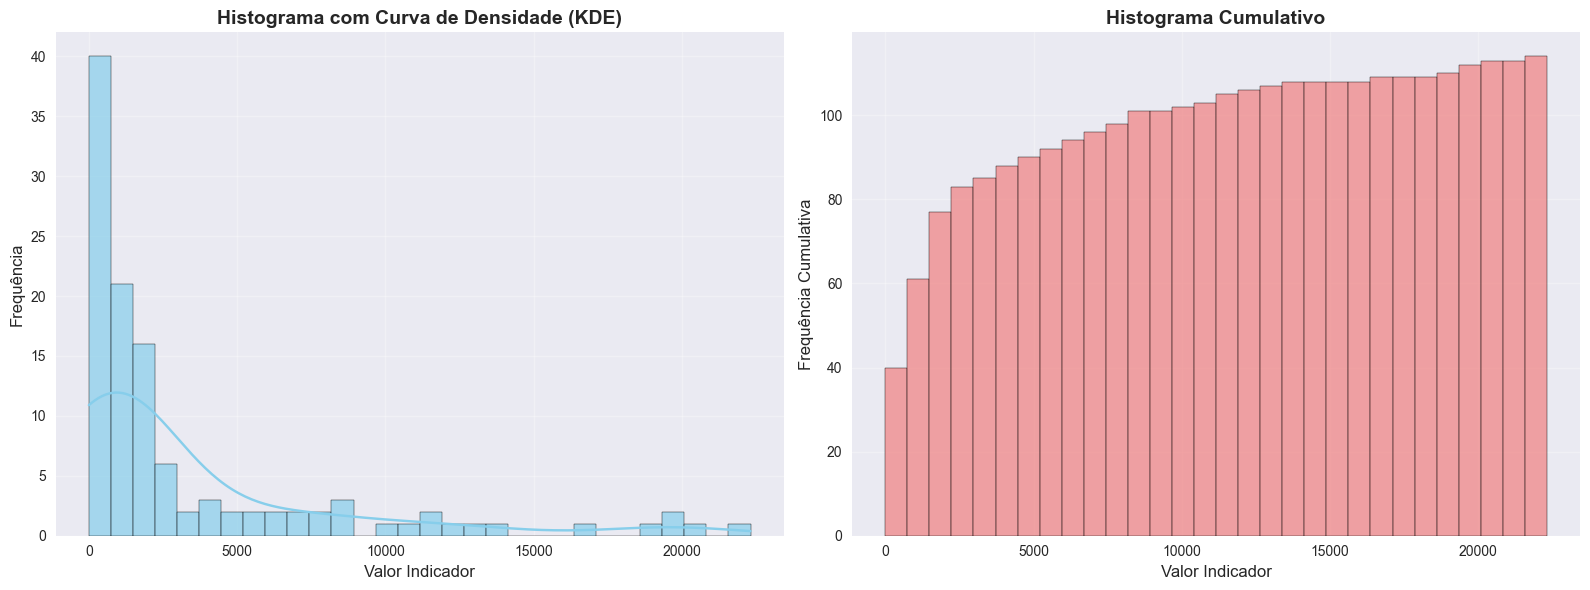


RESUMO DESCRITIVO - HISTOGRAMA:
   • O histograma mostra a distribuição de frequências dos valores indicadores.
   • A curva KDE (Kernel Density Estimation) suaviza a distribuição.
   • O histograma cumulativo mostra a acumulação de frequências.
   • Padrões observados: [Analisar visualmente - assimetria, multimodalidade, etc.]


In [96]:
if 'valor_indicador' in cito_mamo.columns:

    print("HISTOGRAMA - Distribuição de Frequências")
    print("-" * 60)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    sns.histplot(data=cito_mamo, x='valor_indicador', bins=30, kde=True, ax=ax1, color='skyblue', alpha=0.7)
    ax1.set_title('Histograma com Curva de Densidade (KDE)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Valor Indicador')
    ax1.set_ylabel('Frequência')
    ax1.grid(True, alpha=0.3)

    sns.histplot(data=cito_mamo, x='valor_indicador', bins=30, cumulative=True, ax=ax2, color='lightcoral', alpha=0.7)
    ax2.set_title('Histograma Cumulativo', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Valor Indicador')
    ax2.set_ylabel('Frequência Cumulativa')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nRESUMO DESCRITIVO - HISTOGRAMA:")
    print("   • O histograma mostra a distribuição de frequências dos valores indicadores.")
    print("   • A curva KDE (Kernel Density Estimation) suaviza a distribuição.")
    print("   • O histograma cumulativo mostra a acumulação de frequências.")
    print("   • Padrões observados: [Analisar visualmente - assimetria, multimodalidade, etc.]")


else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")

##### _BOXPLOT - Análise de Outliers e Quartis_


BOXPLOT - Análise de Outliers e Quartis
------------------------------------------------------------


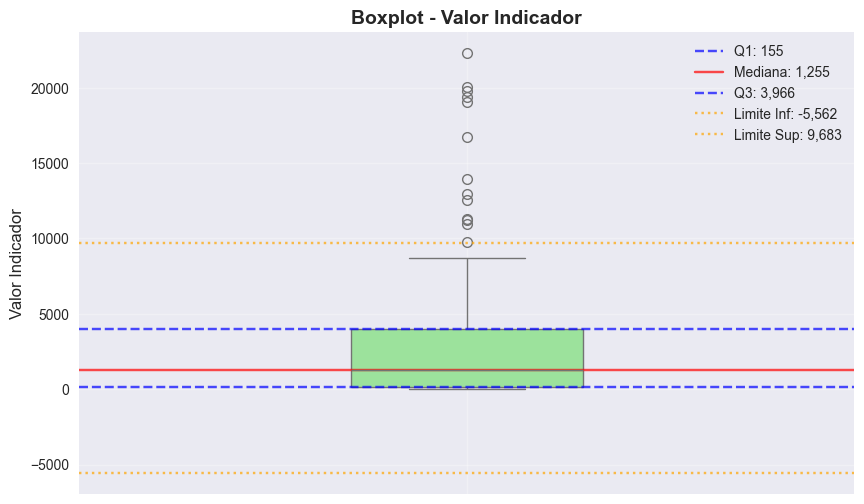


RESUMO DESCRITIVO - BOXPLOT:
   • A caixa representa o IQR (Q1 a Q3 - 50% central dos dados).
   • A linha dentro da caixa é a mediana (Q2).
   • Os 'bigodes' mostram a variação normal dos dados.
   • Pontos fora dos bigodes são outliers.
   • Neste caso: 13 outliers detectados.


In [94]:
if 'valor_indicador' in cito_mamo.columns:

    print(f"\nBOXPLOT - Análise de Outliers e Quartis")
    print("-" * 60)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=cito_mamo, y='valor_indicador', ax=ax, color='lightgreen', width=0.3)
    ax.set_title('Boxplot - Valor Indicador', fontsize=14, fontweight='bold')
    ax.set_ylabel('Valor Indicador')
    ax.grid(True, alpha=0.3)

    q1 = cito_mamo['valor_indicador'].quantile(0.25)
    q2 = cito_mamo['valor_indicador'].quantile(0.50)
    q3 = cito_mamo['valor_indicador'].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    ax.axhline(y=q1, color='blue', linestyle='--', alpha=0.7, label=f'Q1: {q1:,.0f}')
    ax.axhline(y=q2, color='red', linestyle='-', alpha=0.7, label=f'Mediana: {q2:,.0f}')
    ax.axhline(y=q3, color='blue', linestyle='--', alpha=0.7, label=f'Q3: {q3:,.0f}')
    ax.axhline(y=limite_inferior, color='orange', linestyle=':', alpha=0.7, label=f'Limite Inf: {limite_inferior:,.0f}')
    ax.axhline(y=limite_superior, color='orange', linestyle=':', alpha=0.7, label=f'Limite Sup: {limite_superior:,.0f}')

    ax.legend()
    plt.show()

    print("\nRESUMO DESCRITIVO - BOXPLOT:")
    print("   • A caixa representa o IQR (Q1 a Q3 - 50% central dos dados).")
    print("   • A linha dentro da caixa é a mediana (Q2).")
    print("   • Os 'bigodes' mostram a variação normal dos dados.")
    print("   • Pontos fora dos bigodes são outliers.")
    print(f"   • Neste caso: {len(cito_mamo[(cito_mamo['valor_indicador'] < limite_inferior) | (cito_mamo['valor_indicador'] > limite_superior)])} outliers detectados.")

else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")

##### _GRÁFICO DE DISPERSÃO - Relações entre Variáveis_


GRÁFICO DE DISPERSÃO - Relações entre Variáveis
------------------------------------------------------------


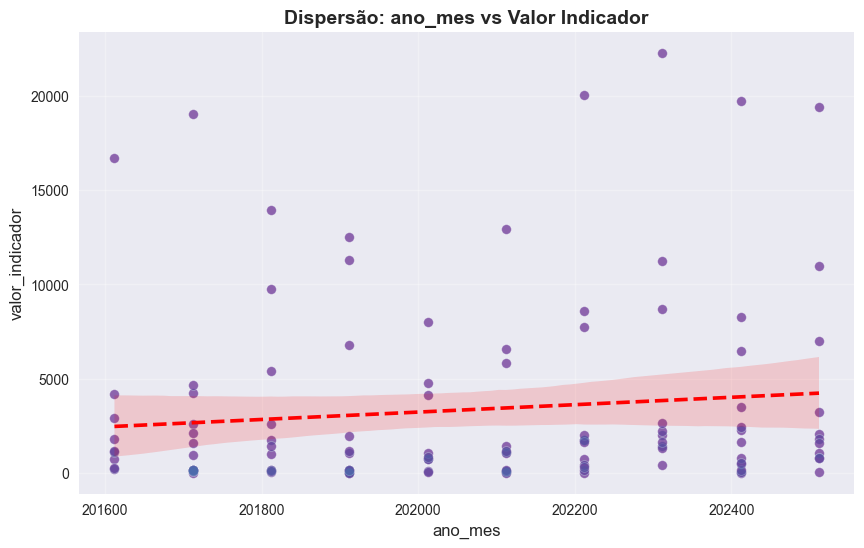


RESUMO DESCRITIVO - DISPERSÃO:
   • Análise da relação entre 'ano_mes' e 'valor_indicador'.
   • Correlação de Pearson: 0.113
   • Correlação FRACA ou inexistente.


In [95]:
if 'valor_indicador' in cito_mamo.columns:

    print(f"\nGRÁFICO DE DISPERSÃO - Relações entre Variáveis")
    print("-" * 60)

    numeric_cols = cito_mamo.select_dtypes(include=['float64', 'int64']).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col != 'valor_indicador']

    if len(numeric_cols) > 0:
        scatter_col = numeric_cols[0]

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.scatterplot(data=cito_mamo, x=scatter_col, y='valor_indicador', ax=ax, alpha=0.6, color='purple')
        ax.set_title(f'Dispersão: {scatter_col} vs Valor Indicador', fontsize=14, fontweight='bold')
        ax.set_xlabel(scatter_col)
        ax.set_ylabel('Valor Indicador')
        ax.grid(True, alpha=0.3)

        try:
            sns.regplot(data=cito_mamo, x=scatter_col, y='valor_indicador', ax=ax,
                       scatter_kws={'alpha':0.3}, line_kws={'color':'red', 'linestyle':'--'})
        except:
            pass

        plt.show()

        corr = cito_mamo[scatter_col].corr(cito_mamo['valor_indicador'])
        print("\nRESUMO DESCRITIVO - DISPERSÃO:")
        print(f"   • Análise da relação entre '{scatter_col}' e 'valor_indicador'.")
        print(f"   • Correlação de Pearson: {corr:.3f}")
        if abs(corr) > 0.7:
            print("   • Correlação FORTE detectada!")
        elif abs(corr) > 0.3:
            print("   • Correlação MODERADA detectada.")
        else:
            print("   • Correlação FRACA ou inexistente.")
    else:
        print("Não há outras colunas numéricas para análise de dispersão.")

else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")

##### _HEATMAP DE CORRELAÇÃO - Relações entre Todas as Variáveis Numéricas_


HEATMAP DE CORRELAÇÃO - Relações entre Todas as Variáveis Numéricas
------------------------------------------------------------


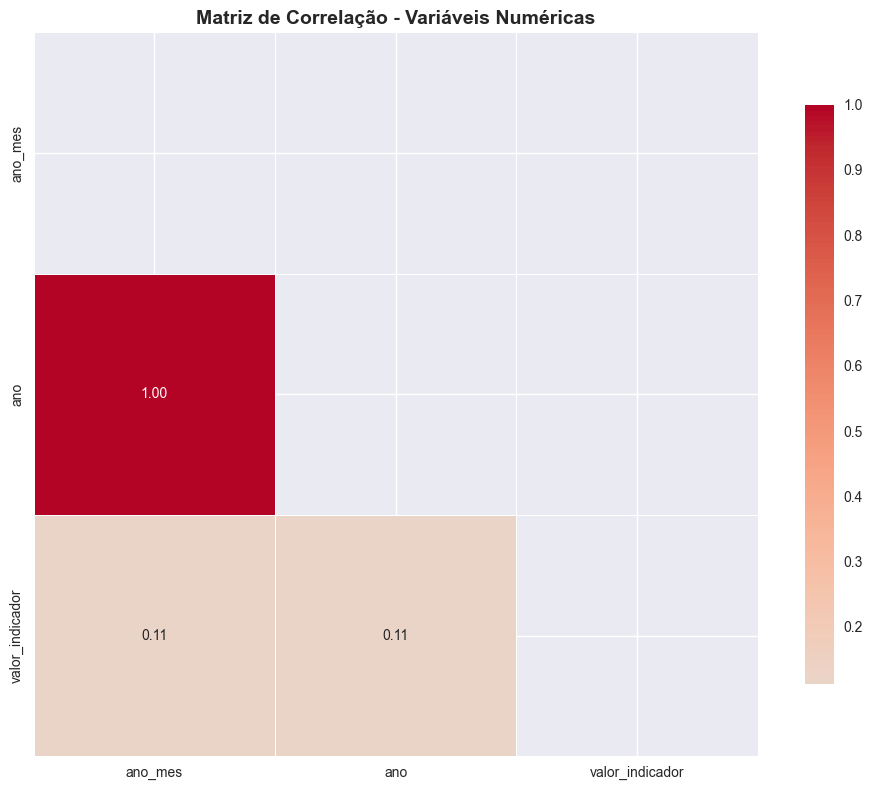


RESUMO DESCRITIVO - HEATMAP:
   • Valores próximos de +1: Correlação positiva forte
   • Valores próximos de -1: Correlação negativa forte
   • Valores próximos de 0: Correlação fraca ou inexistente
   • Correlações > 0.7 ou < -0.7 são consideradas fortes

Correlações Fortes Detectadas:
   • ano_mes ↔ ano: 1.000


In [98]:
if 'valor_indicador' in cito_mamo.columns:

    print(f"\nHEATMAP DE CORRELAÇÃO - Relações entre Todas as Variáveis Numéricas")
    print("-" * 60)

    if len(numeric_cols) > 1:
        all_numeric = numeric_cols + ['valor_indicador']

        corr_matrix = cito_mamo[all_numeric].corr()

        fig, ax = plt.subplots(figsize=(10, 8))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Máscara para triangular superior
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
                   square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, mask=mask, ax=ax)
        ax.set_title('Matriz de Correlação - Variáveis Numéricas', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print("\nRESUMO DESCRITIVO - HEATMAP:")
        print("   • Valores próximos de +1: Correlação positiva forte")
        print("   • Valores próximos de -1: Correlação negativa forte")
        print("   • Valores próximos de 0: Correlação fraca ou inexistente")
        print("   • Correlações > 0.7 ou < -0.7 são consideradas fortes")

        strong_corr = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                corr_val = corr_matrix.iloc[i, j]
                if abs(corr_val) > 0.7:
                    strong_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))

        if strong_corr:
            print("\nCorrelações Fortes Detectadas:")
            for var1, var2, corr in strong_corr:
                print(f"   • {var1} ↔ {var2}: {corr:.3f}")
        else:
            print("\nNenhuma correlação forte detectada entre as variáveis.")
    else:
        print("Poucas colunas numéricas para análise de correlação.")


else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")

##### _QQ-PLOT - Verificação de Normalidade_


QQ-PLOT - Verificação de Normalidade
------------------------------------------------------------


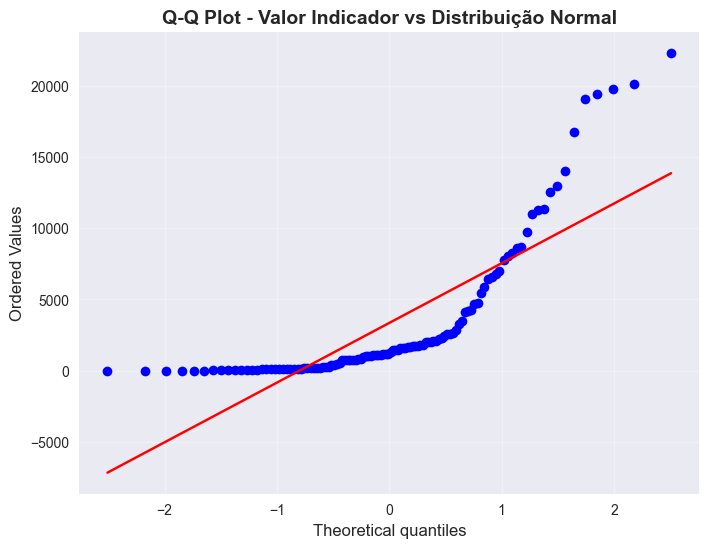


RESUMO DESCRITIVO - QQ-PLOT:
   • O Q-Q plot compara os quantis dos dados com uma distribuição normal.
   • Pontos próximos da linha diagonal indicam normalidade.
   • Desvios da linha indicam não-normalidade.
   • Teste de Shapiro-Wilk: Estatística = 0.6775, p-valor = 0.0000
   • Conclusão: Dados NÃO seguem distribuição normal (p ≤ 0.05)


In [99]:
if 'valor_indicador' in cito_mamo.columns:

    print(f"\nQQ-PLOT - Verificação de Normalidade")
    print("-" * 60)

    from scipy import stats

    fig, ax = plt.subplots(figsize=(8, 6))
    stats.probplot(cito_mamo['valor_indicador'].dropna(), dist="norm", plot=ax)
    ax.set_title('Q-Q Plot - Valor Indicador vs Distribuição Normal', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.show()

    try:
        stat, p_value = stats.shapiro(cito_mamo['valor_indicador'].dropna().sample(min(5000, len(cito_mamo))))
        print("\nRESUMO DESCRITIVO - QQ-PLOT:")
        print("   • O Q-Q plot compara os quantis dos dados com uma distribuição normal.")
        print("   • Pontos próximos da linha diagonal indicam normalidade.")
        print("   • Desvios da linha indicam não-normalidade.")
        print(f"   • Teste de Shapiro-Wilk: Estatística = {stat:.4f}, p-valor = {p_value:.4f}")
        if p_value > 0.05:
            print("   • Conclusão: Dados parecem seguir distribuição normal (p > 0.05)")
        else:
            print("   • Conclusão: Dados NÃO seguem distribuição normal (p ≤ 0.05)")
    except:
        print("Não foi possível realizar o teste de normalidade.")

else:
    print("Coluna 'valor_indicador' não encontrada no dataset!")

VISUALIZAÇÕES REALIZADAS: <br>
   • Histograma com KDE e cumulativo<br>
   • Boxplot com identificação de outliers<br>
   • Gráfico de dispersão<br>
   • Gráfico de barras <br>
   • Heatmap de correlação <br>
   • Q-Q plot para normalidade<br>

INSIGHTS PRINCIPAIS:<br>
   • Analisar a forma da distribuição no histograma<br>
   • Identificar outliers no boxplot<br>
   • Verificar relações lineares no scatter plot<br>
   • Observar padrões categóricos no gráfico de barras<br>
   • Detectar multicolinearidade no heatmap<br>
   • Avaliar normalidade no Q-Q plot

##### _GRÁFICO DE BARRAS: DISTRIBUIÇÃO POR ANO E CIDADE - EVOLUÇÃO TEMPORAL_

GRÁFICO DE BARRAS: DISTRIBUIÇÃO POR ANO E CIDADE - EVOLUÇÃO TEMPORAL



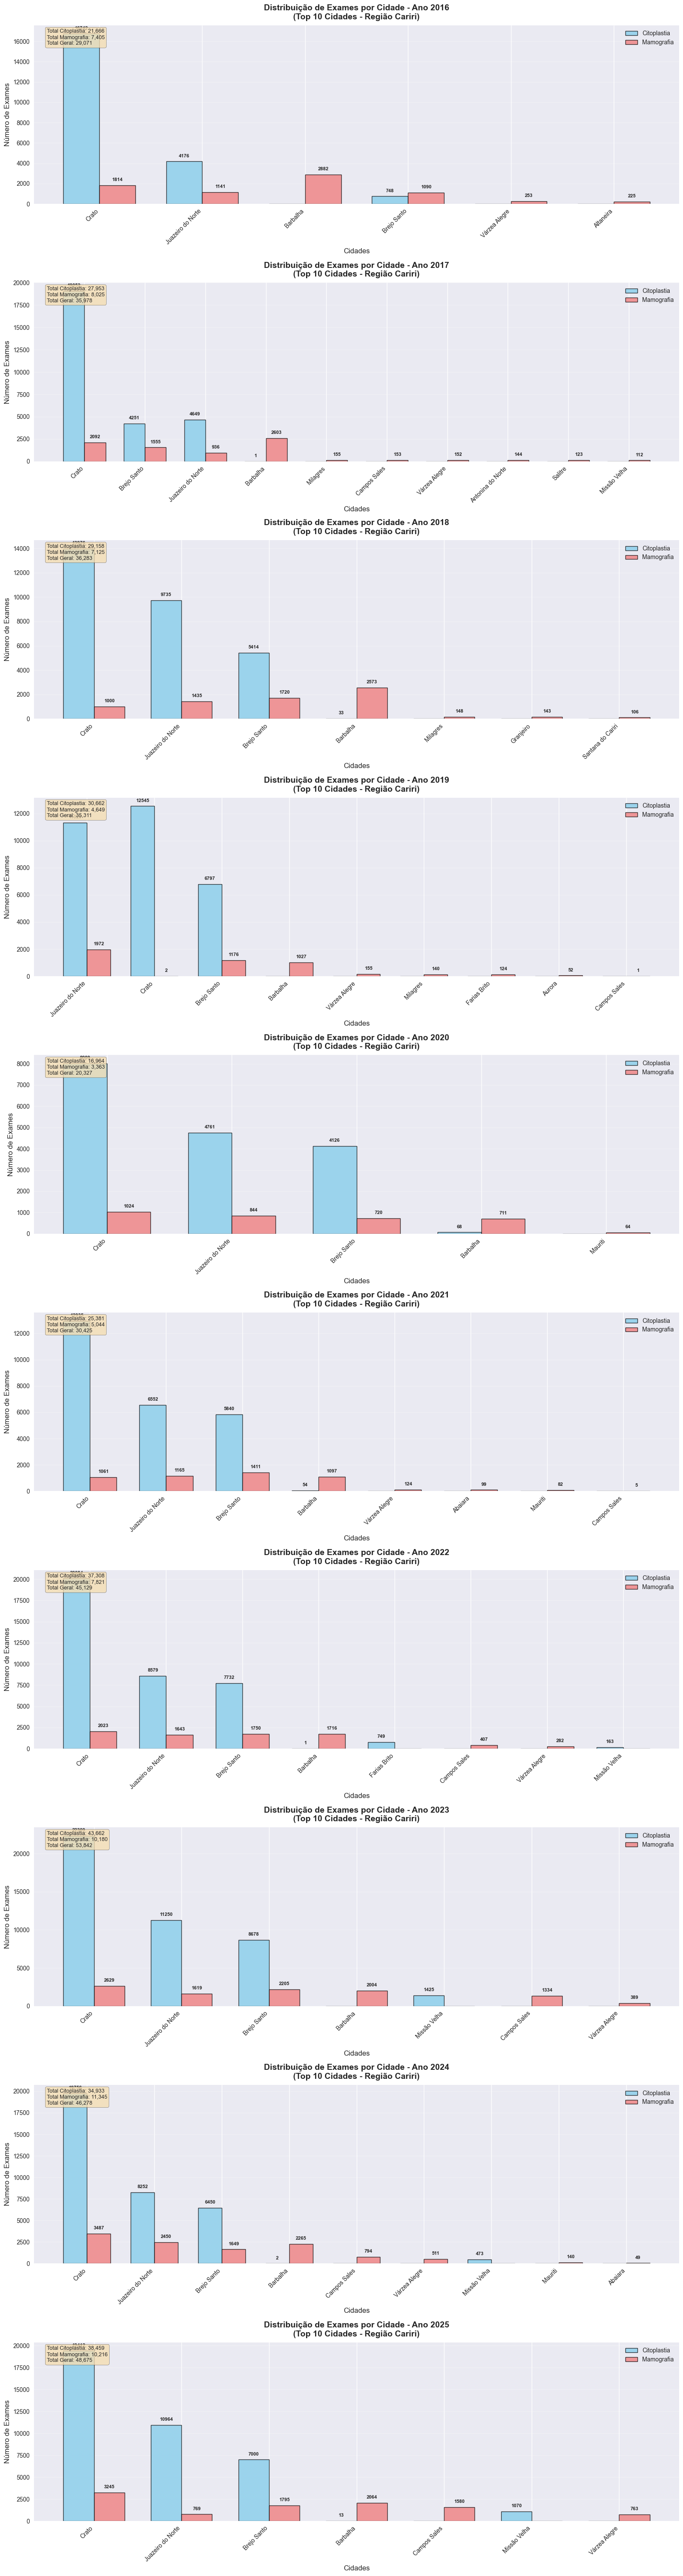

ESTATÍSTICAS GERAIS POR ANO:
------------------------------------------------------------
Ano 2016:
  • Cidades com dados: 6
  • Total Citoplastia: 21,666
  • Total Mamografia: 7,405
  • Total Geral: 29,071
  • Proporção Citoplastia: 74.5%
  • Proporção Mamografia: 25.5%

Ano 2017:
  • Cidades com dados: 11
  • Total Citoplastia: 27,953
  • Total Mamografia: 8,091
  • Total Geral: 36,044
  • Proporção Citoplastia: 77.6%
  • Proporção Mamografia: 22.4%

Ano 2018:
  • Cidades com dados: 7
  • Total Citoplastia: 29,158
  • Total Mamografia: 7,125
  • Total Geral: 36,283
  • Proporção Citoplastia: 80.4%
  • Proporção Mamografia: 19.6%

Ano 2019:
  • Cidades com dados: 9
  • Total Citoplastia: 30,662
  • Total Mamografia: 4,649
  • Total Geral: 35,311
  • Proporção Citoplastia: 86.8%
  • Proporção Mamografia: 13.2%

Ano 2020:
  • Cidades com dados: 5
  • Total Citoplastia: 16,964
  • Total Mamografia: 3,363
  • Total Geral: 20,327
  • Proporção Citoplastia: 83.5%
  • Proporção Mamografia: 1

In [86]:
print("GRÁFICO DE BARRAS: DISTRIBUIÇÃO POR ANO E CIDADE - EVOLUÇÃO TEMPORAL\n")

if 'valor_indicador' in cito_mamo.columns and 'ano_mes' in cito_mamo.columns and 'municipio' in cito_mamo.columns:
    cito_mamo['ano'] = cito_mamo['ano_mes'].astype(str).str[:4].astype(int)

    cito_data = cito_mamo[cito_mamo['tipo_exame'] == 'Citopatologico'].copy()
    mamo_data = cito_mamo[cito_mamo['tipo_exame'] == 'Mamografia'].copy()

    cito_year_city = cito_data.groupby(['ano', 'municipio'])['valor_indicador'].sum().reset_index()
    cito_year_city.columns = ['Ano', 'Cidade', 'Citoplastia']

    mamo_year_city = mamo_data.groupby(['ano', 'municipio'])['valor_indicador'].sum().reset_index()
    mamo_year_city.columns = ['Ano', 'Cidade', 'Mamografia']

    year_city_data = pd.merge(cito_year_city, mamo_year_city, on=['Ano', 'Cidade'], how='outer').fillna(0)

    anos_unicos = sorted(year_city_data['Ano'].unique())

    fig, axes = plt.subplots(len(anos_unicos), 1, figsize=(16, 6 * len(anos_unicos)))
    if len(anos_unicos) == 1:
        axes = [axes]

    for i, ano in enumerate(anos_unicos):
        ax = axes[i]

        data_ano = year_city_data[year_city_data['Ano'] == ano].copy()

        data_ano['Total'] = data_ano['Citoplastia'] + data_ano['Mamografia']
        data_ano_top = data_ano.nlargest(10, 'Total')

        if len(data_ano_top) > 0:
            x = np.arange(len(data_ano_top))
            width = 0.35

            bars1 = ax.bar(x - width/2, data_ano_top['Citoplastia'], width, label='Citoplastia',
                          color='skyblue', alpha=0.8, edgecolor='black', linewidth=1)

            bars2 = ax.bar(x + width/2, data_ano_top['Mamografia'], width, label='Mamografia',
                          color='lightcoral', alpha=0.8, edgecolor='black', linewidth=1)

            ax.set_title(f'Distribuição de Exames por Cidade - Ano {ano}\n(Top 10 Cidades - Região Cariri)',
                        fontsize=14, fontweight='bold', pad=10)
            ax.set_xlabel('Cidades', fontsize=12)
            ax.set_ylabel('Número de Exames', fontsize=12)
            ax.set_xticks(x)
            ax.set_xticklabels(data_ano_top['Cidade'], rotation=45, ha='right', fontsize=10)
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3, axis='y')

            max_height = max(data_ano_top['Citoplastia'].max(), data_ano_top['Mamografia'].max())
            for bar in bars1:
                height = bar.get_height()
                if height > 0:
                    ax.text(bar.get_x() + bar.get_width()/2., height + max_height * 0.02,
                           f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=8)

            for bar in bars2:
                height = bar.get_height()
                if height > 0:
                    ax.text(bar.get_x() + bar.get_width()/2., height + max_height * 0.02,
                           f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=8)

            total_cito = data_ano_top['Citoplastia'].sum()
            total_mamo = data_ano_top['Mamografia'].sum()
            total_geral = total_cito + total_mamo

            ax.text(0.02, 0.98, f'Total Citoplastia: {total_cito:,.0f}\nTotal Mamografia: {total_mamo:,.0f}\nTotal Geral: {total_geral:,.0f}',
                   transform=ax.transAxes, fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

        else:
            ax.text(0.5, 0.5, f'Sem dados para o ano {ano}', ha='center', va='center', fontsize=12)
            ax.set_title(f'Ano {ano} - Sem Dados Disponíveis', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("ESTATÍSTICAS GERAIS POR ANO:")
    print("-" * 60)

    for ano in anos_unicos:
        data_ano = year_city_data[year_city_data['Ano'] == ano]
        total_cidades = data_ano['Cidade'].nunique()
        total_cito = data_ano['Citoplastia'].sum()
        total_mamo = data_ano['Mamografia'].sum()
        total_geral = total_cito + total_mamo

        print(f"Ano {ano}:")
        print(f"  • Cidades com dados: {total_cidades}")
        print(f"  • Total Citoplastia: {total_cito:,.0f}")
        print(f"  • Total Mamografia: {total_mamo:,.0f}")
        print(f"  • Total Geral: {total_geral:,.0f}")
        if total_geral > 0:
            print(f"  • Proporção Citoplastia: {total_cito/total_geral*100:.1f}%")
            print(f"  • Proporção Mamografia: {total_mamo/total_geral*100:.1f}%")
        print()

    print("TABELA DETALHADA POR ANO (Top 5 Cidades por Ano):")
    print("-" * 80)

    for ano in anos_unicos:
        data_ano = year_city_data[year_city_data['Ano'] == ano].copy()
        data_ano['Total'] = data_ano['Citoplastia'] + data_ano['Mamografia']
        data_ano_top5 = data_ano.nlargest(5, 'Total')

        if len(data_ano_top5) > 0:
            print(f"\nAno {ano}:")
            print(data_ano_top5[['Cidade', 'Citoplastia', 'Mamografia', 'Total']].to_string(
                index=False, formatters={'Citoplastia': '{:,.0f}'.format, 'Mamografia': '{:,.0f}'.format, 'Total': '{:,.0f}'.format}))
        else:
            print(f"\nAno {ano}: Sem dados disponíveis")

else:
    print("Colunas necessárias não encontradas no dataset!")
    print("Colunas necessárias: 'valor_indicador', 'ano_mes', 'municipio', 'tipo_exame'")
    print("Colunas disponíveis:", cito_mamo.columns.tolist())

INTERPRETAÇÃO DOS GRÁFICOS:<br>
• Cada subplot representa um ano diferente <br>
• Barras azuis: Exames de citoplastia por cidade <br>
• Barras vermelhas: Exames de mamografia por cidade <br>
• Top 10 cidades: Ordenadas por volume total de exames <br>
• Comparação temporal: Permite ver evolução ano a ano <br>

INSIGHTS PARA ANÁLISE TEMPORAL: <br>
• Cidades que mantêm ou aumentam cobertura ao longo dos anos <br>
• Diferenças na adoção de citoplastia vs mamografia por período <br>
• Identificação de cidades com queda na cobertura preventiva <br>
• Padrões sazonais ou tendências regionais

##### _Gráfico de barras: Distribuido por cidade e acumulo geral_

GRÁFICO DE BARRAS: DISTRIBUIÇÃO POR CIDADES - CITOPLASTIA vs MAMOGRAFIA


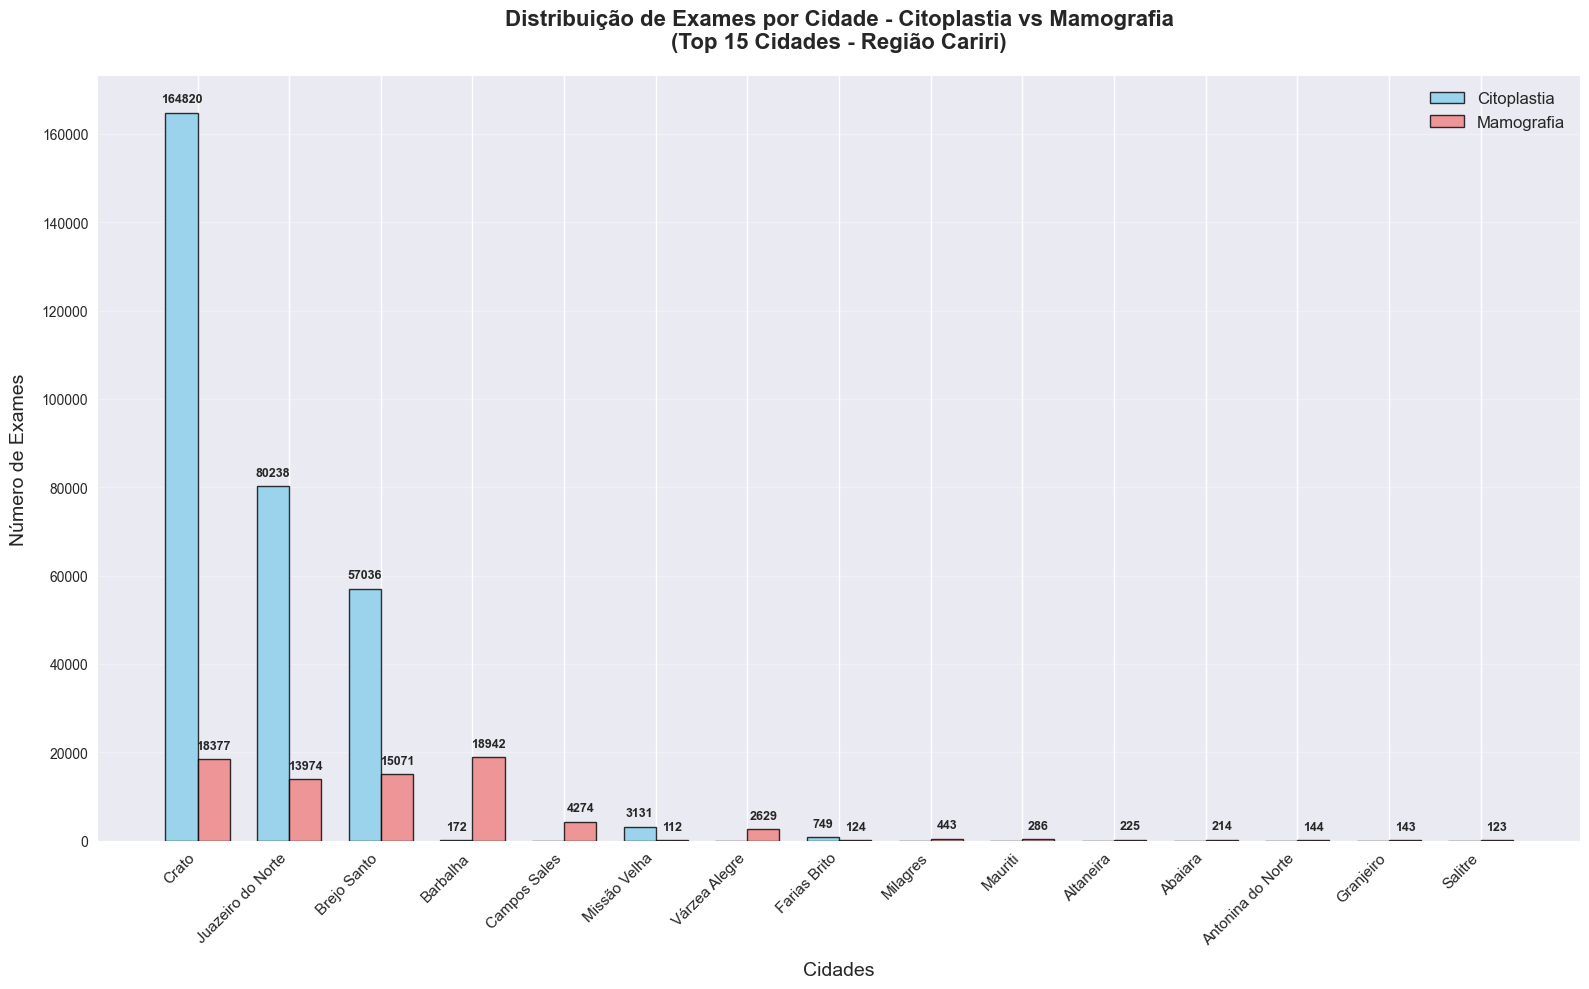

ESTATÍSTICAS DO GRÁFICO:
--------------------------------------------------
Total de cidades analisadas: 17
Cidades mostradas no gráfico: 15 (top 15)
Total de exames citoplastia: 306,146.0
Total de exames mamografia: 75,239.0
Proporção citoplastia: 80.3%
Proporção mamografia: 19.7%

TOP CIDADES:
• Maior número de citoplastia: Crato (164,820.0 exames)
• Maior número de mamografia: Barbalha (18,942.0 exames)

TABELA DETALHADA (Top 15 Cidades):
--------------------------------------------------------------------------------
           Cidade Citoplastia Mamografia     Total
            Crato   164,820.0   18,377.0 183,197.0
Juazeiro do Norte    80,238.0   13,974.0  94,212.0
      Brejo Santo    57,036.0   15,071.0  72,107.0
         Barbalha       172.0   18,942.0  19,114.0
     Campos Sales         0.0    4,274.0   4,274.0
     Missão Velha     3,131.0      112.0   3,243.0
    Várzea Alegre         0.0    2,629.0   2,629.0
     Farias Brito       749.0      124.0     873.0
         Milag

In [ ]:
print("GRÁFICO DE BARRAS: DISTRIBUIÇÃO POR CIDADES - CITOPLASTIA vs MAMOGRAFIA")

required_cols = {'valor_indicador', 'municipio', 'tipo_exame'}
if required_cols.issubset(set(cito_mamo.columns)):
    cito_mask = cito_mamo['tipo_exame'].astype(str).str.contains('cito', case=False, na=False)
    mamo_mask = cito_mamo['tipo_exame'].astype(str).str.contains('mamo', case=False, na=False)

    cito_group = (
        cito_mamo[cito_mask]
        .groupby('municipio', as_index=False)['valor_indicador']
        .sum()
        .rename(columns={'valor_indicador': 'Citoplastia'})
    )

    mamo_group = (
        cito_mamo[mamo_mask]
        .groupby('municipio', as_index=False)['valor_indicador']
        .sum()
        .rename(columns={'valor_indicador': 'Mamografia'})
    )

    city_exams = pd.merge(cito_group, mamo_group, on='municipio', how='outer').fillna(0)
    city_exams.columns = ['Cidade', 'Citoplastia', 'Mamografia']
    city_exams['Total'] = city_exams['Citoplastia'] + city_exams['Mamografia']

    city_exams_top = city_exams.nlargest(15, 'Total').reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(16, 10))
    x = np.arange(len(city_exams_top))
    width = 0.35

    bars1 = ax.bar(x - width/2, city_exams_top['Citoplastia'], width, label='Citoplastia',
                  color='skyblue', alpha=0.8, edgecolor='black', linewidth=1)
    bars2 = ax.bar(x + width/2, city_exams_top['Mamografia'], width, label='Mamografia',
                  color='lightcoral', alpha=0.8, edgecolor='black', linewidth=1)

    ax.set_title('Distribuição de Exames por Cidade - Citoplastia vs Mamografia\n(Top 15 Cidades - Região Cariri)',
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Cidades', fontsize=14, labelpad=10)
    ax.set_ylabel('Número de Exames', fontsize=14, labelpad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(city_exams_top['Cidade'], rotation=45, ha='right', fontsize=11)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')

    max_height = max(city_exams_top['Citoplastia'].max(), city_exams_top['Mamografia'].max())
    for bar in bars1:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + max_height * 0.01,
                    f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + max_height * 0.01,
                    f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=9)

    plt.tight_layout()
    plt.show()

    print("ESTATÍSTICAS DO GRÁFICO:")
    print("-" * 50)
    print(f"Total de cidades analisadas: {len(city_exams)}")
    print(f"Cidades mostradas no gráfico: {len(city_exams_top)} (top 15)")
    print(f"Total de exames citoplastia: {city_exams['Citoplastia'].sum():,}")
    print(f"Total de exames mamografia: {city_exams['Mamografia'].sum():,}")
    total_geral = city_exams['Total'].sum()
    if total_geral > 0:
        print(f"Proporção citoplastia: {city_exams['Citoplastia'].sum() / total_geral * 100:.1f}%")
        print(f"Proporção mamografia: {city_exams['Mamografia'].sum() / total_geral * 100:.1f}%")

    if len(city_exams_top) > 0:
        top_cito = city_exams_top.loc[city_exams_top['Citoplastia'].idxmax()]
        top_mamo = city_exams_top.loc[city_exams_top['Mamografia'].idxmax()]

        print(f"\nTOP CIDADES:")
        print(f"• Maior número de citoplastia: {top_cito['Cidade']} ({top_cito['Citoplastia']:,} exames)")
        print(f"• Maior número de mamografia: {top_mamo['Cidade']} ({top_mamo['Mamografia']:,} exames)")

    print(f"\nTABELA DETALHADA (Top 15 Cidades):")
    print("-" * 80)
    pd.set_option('display.max_rows', None)
    print(city_exams_top[['Cidade', 'Citoplastia', 'Mamografia', 'Total']].to_string(
        index=False,
        formatters={'Citoplastia': '{:,}'.format, 'Mamografia': '{:,}'.format, 'Total': '{:,}'.format}
    ))

    print(f"\nINTERPRETAÇÃO:")
    print("• Os valores são os somatórios reais de todos os anos, agrupados por cidade e tipo de exame.")
    print("• Barras azuis: Exames de citoplastia por cidade.")
    print("• Barras vermelhas: Exames de mamografia por cidade.")
    print("• O gráfico mostra as 15 cidades com maior volume total de exames.")

else:
    missing = required_cols.difference(set(cito_mamo.columns))
    print("Colunas necessárias não encontradas no dataset:", missing)
    print("Colunas disponíveis:", cito_mamo.columns.tolist())